In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("NIFTY_50__EQ__INDICES__NSE__MINUTE.csv")
data.drop(columns=["volume", "timestamp"], inplace=True)
data.dropna(inplace=True)

a = data.to_numpy()

split = int(len(a) * 0.8)

train_data = a[:split]
test_data = a[split:]

scaler = StandardScaler()

train_data = scaler.fit_transform(train_data)
test_data = scaler.transform(test_data)

def create_sequence(data, window):
    X = []
    Y = []
    for i in range(len(data) - window):
        X.append(data[i:i + window])
        Y.append(data[i + window][3])
    return np.array(X), np.array(Y)

window = 60

trainx, trainy = create_sequence(train_data, window)
testx, testy = create_sequence(test_data, window)

trainx = torch.tensor(trainx, dtype=torch.float32)
trainy = torch.tensor(trainy, dtype=torch.float32).unsqueeze(1)

testx = torch.tensor(testx, dtype=torch.float32)
testy = torch.tensor(testy, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(trainx, trainy)
test_dataset = TensorDataset(testx, testy)

train_loader = DataLoader(
    train_dataset,
    batch_size=164,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=164,
    pin_memory=True
)

In [3]:
class RnnNet(nn.Module):
    def __init__(self, in_size, hid_size, out_size):
        super().__init__()
        self.hidden = hid_size
        self.rnn = nn.RNNCell(in_size, hid_size)
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hid_size, out_size)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape

        h = torch.zeros(batch_size, self.hidden, device=x.device)

        for t in range(seq_len):
            h = self.rnn(x[:, t, :], h)

        h = self.dropout(h)

        return self.fc(h)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RnnNet(4, 124, 1).to(device)

loss_fn = nn.MSELoss()

optimizer = Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

epochs = 5
best = float("inf")

train_losses = []
val_losses = []

In [4]:
for epoch in range(epochs):

    model.train()

    train_loss = 0

    for x, y in train_loader:

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        pred = model(x)

        loss = loss_fn(pred, y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    train_losses.append(train_loss)

    model.eval()

    val_loss = 0

    with torch.no_grad():

        for x, y in test_loader:

            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            pred = model(x)

            val_loss += loss_fn(pred, y).item()

    val_loss /= len(test_loader)

    val_losses.append(val_loss)

    if val_loss < best:
        best = val_loss
        torch.save(model.state_dict(), "best_rnn.pt")

    print(
        f"Epoch {epoch+1:02d} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f}"
    )

Epoch 01 | Train Loss: 0.089213 | Val Loss: 0.049779
Epoch 02 | Train Loss: 0.003070 | Val Loss: 0.038440
Epoch 03 | Train Loss: 0.002692 | Val Loss: 0.032747
Epoch 04 | Train Loss: 0.002523 | Val Loss: 0.030231
Epoch 05 | Train Loss: 0.002494 | Val Loss: 0.024124


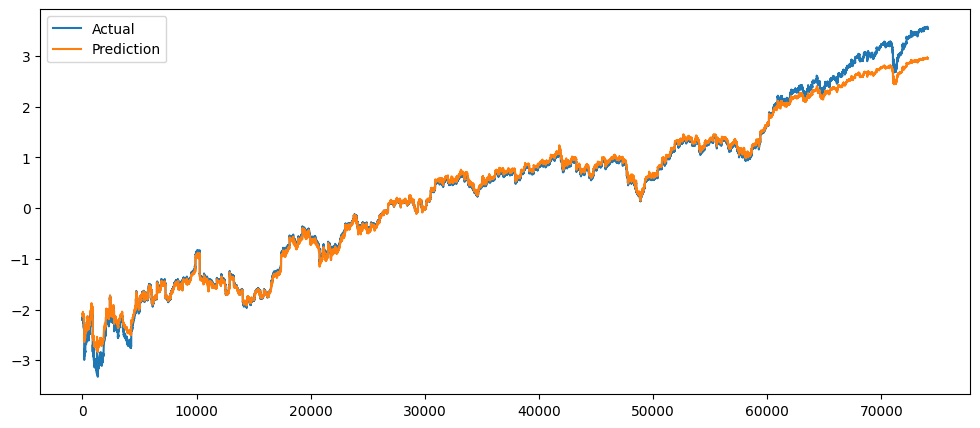

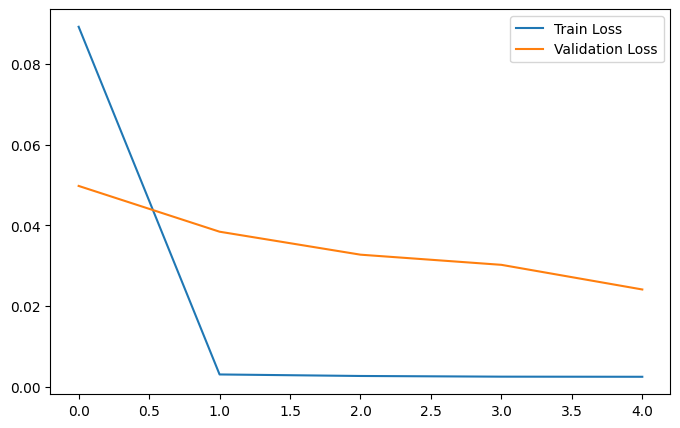

In [5]:
model.load_state_dict(torch.load("best_rnn.pt", map_location=device))
model.eval()

predictions = []

with torch.no_grad():

    for x, _ in test_loader:

        x = x.to(device)

        pred = model(x)

        predictions.append(pred.cpu())

predictions = torch.cat(predictions).numpy()
actual = testy.numpy()

plt.figure(figsize=(12, 5))
plt.plot(actual, label="Actual")
plt.plot(predictions, label="Prediction")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.show()